Question 1: Python Basics and Data Manipulation

Objective: Demonstrate basic Python skills and data manipulation using Pandas.

In [1]:
# Importing pandas for data manipulation, and matplotlib for visualisation:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Loading a given CSV file containing metal prices into a Pandas DataFrame:

In [2]:
 # Loading the provided CSV file into a Pandas DataFrame:
 df = pd.read_csv("../data/MarketData.csv")

Exploratory Data Analysis:

To get an understanding of the data at hand, snapshots of the data are retrieved and seen below.

In [3]:
# Displaying the first few rows of the DataFrame to understand what the data looks like:
df.head()

,Start Date,01/01/2010,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,End Date,01/01/2023,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,LME COPPER 3MO ($),LME ALUMINUM 3MO ($),LME ZINC 3MO ($),LME LEAD 3MO ($),LME TIN 3MO ($),Generic 1st 'CL' Future
3,NaN,LMCADS03 Comdty,LMAHDS03 Comdty,LMZSDS03 Comdty,LMPBDS03 Comdty,LMSNDS03 Comdty,CL1 Comdty
4,NaN,Settlement Price,Settlement Price,Settlement Price,Settlement Price,Settlement Price,Settlement Price


In [ ]:
# Displaying the last few rows of the DataFrame to also understand what the data looks like:
df.tail()

,Start Date,01/01/2010,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
3392,26/12/2022,8349.5,2389.5,2965,2273.5,23934,79.56
3393,27/12/2022,8349.5,2389.5,2965,2273.5,23934,79.53
3394,28/12/2022,8443,2381,3005.5,2218,24734,78.96
3395,29/12/2022,8418,2405,2984.5,2272.5,24915,78.4
3396,30/12/2022,8372,2378,2972.5,2293,24808,80.26


Since the first few rows in the DataFrame seem to be metadata and not the actual data itself, the first 10 rows have specifically been called to retrieve and understand the data:

In [5]:
# Displaying the first 10 rows of the DataFrame to get a better understanding and view the rows with the data,
# and not the metadata:
df.head(10)

,Start Date,01/01/2010,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,End Date,01/01/2023,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,LME COPPER 3MO ($),LME ALUMINUM 3MO ($),LME ZINC 3MO ($),LME LEAD 3MO ($),LME TIN 3MO ($),Generic 1st 'CL' Future
3,NaN,LMCADS03 Comdty,LMAHDS03 Comdty,LMZSDS03 Comdty,LMPBDS03 Comdty,LMSNDS03 Comdty,CL1 Comdty
4,NaN,Settlement Price,Settlement Price,Settlement Price,Settlement Price,Settlement Price,Settlement Price
5,Dates,PX_SETTLE,PX_SETTLE,PX_SETTLE,PX_SETTLE,PX_SETTLE,PX_SETTLE
6,01/01/2010,7375,2230,2560,2432,16950,79.36
7,04/01/2010,7500,2267,2574,2515,17450,81.51
8,05/01/2010,7485,2302,2575,2522.5,17375,81.77
9,06/01/2010,7660,2377,2718,2680,17825,83.18


Since the first six rows are metadata, I will be using this metadata later in the Notebook, but will remove it from the DataFrame as I would like the DataFrame to only contain the data itself for the manipulation and usage of it.

In [ ]:
# The skiprows parameter is used to skip the first 6 rows of the Dataframe, which is the metadata and not the data itself here:
df = pd.read_csv("../data/MarketData.csv", skiprows=6)

To verify that the DataFrame has been updated with removing the metadata from it, I run head() and tail() again:

In [7]:
df.head()

,Dates,PX_SETTLE,PX_SETTLE.1,PX_SETTLE.2,PX_SETTLE.3,PX_SETTLE.4,PX_SETTLE.5
0,01/01/2010,7375.0,2230.0,2560.0,2432.0,16950,79.36
1,04/01/2010,7500.0,2267.0,2574.0,2515.0,17450,81.51
2,05/01/2010,7485.0,2302.0,2575.0,2522.5,17375,81.77
3,06/01/2010,7660.0,2377.0,2718.0,2680.0,17825,83.18
4,07/01/2010,7535.0,2310.0,2607.0,2599.0,17475,82.66


In [8]:
df.tail()

,Dates,PX_SETTLE,PX_SETTLE.1,PX_SETTLE.2,PX_SETTLE.3,PX_SETTLE.4,PX_SETTLE.5
3386,26/12/2022,8349.5,2389.5,2965.0,2273.5,23934,79.56
3387,27/12/2022,8349.5,2389.5,2965.0,2273.5,23934,79.53
3388,28/12/2022,8443.0,2381.0,3005.5,2218.0,24734,78.96
3389,29/12/2022,8418.0,2405.0,2984.5,2272.5,24915,78.40
3390,30/12/2022,8372.0,2378.0,2972.5,2293.0,24808,80.26


Therefore, the DataFrame now contains only the actual data, without the metadata as well in it.

To gain an understanding for further processes of the data, I look at the data types of the current columns of the data in the DataFrame. I do this by carrying out the following:

In [9]:
# Retrives the data types of each column in this DataFrame:
df.dtypes

Dates              str
PX_SETTLE      float64
PX_SETTLE.1    float64
PX_SETTLE.2    float64
PX_SETTLE.3    float64
PX_SETTLE.4      int64
PX_SETTLE.5    float64
dtype: object

Since the Assets were mentioned in the metadata for the respective columns, I use this source of truth to rename the columns of this DataFrame in order to enhance readability and maintainability:

In [10]:
# Columns being renamed in the DataFrame for better readability and understanding of the data:
df = df.rename(columns={
    "PX_SETTLE": "Copper",
    "PX_SETTLE.1": "Aluminum",
    "PX_SETTLE.2": "Zinc",
    "PX_SETTLE.3": "Lead",
    "PX_SETTLE.4": "Tin",
    "PX_SETTLE.5": "CL_Futures"
})

Verifying that the column names have been changes and having a look at what the DataFrame looks like at this stage:

In [11]:
df.head()

,Dates,Copper,Aluminum,Zinc,Lead,Tin,CL_Futures
0,01/01/2010,7375.0,2230.0,2560.0,2432.0,16950,79.36
1,04/01/2010,7500.0,2267.0,2574.0,2515.0,17450,81.51
2,05/01/2010,7485.0,2302.0,2575.0,2522.5,17375,81.77
3,06/01/2010,7660.0,2377.0,2718.0,2680.0,17825,83.18
4,07/01/2010,7535.0,2310.0,2607.0,2599.0,17475,82.66


Therefore, the column names have been updated according to the metadata, and all the changed so far are reflecting in this DataFrame.

Checking for any Missing or Null Values, i.e., this checks for any None or NaN values in the dataFrame:

In [12]:
# The first .sum() calculates the number of missing or null values column-wise, and the second .sum() calculates the same 
# across this entire DataFrame
df.isnull().sum().sum()

np.int64(0)

Therefore, no missing or null values are present in this DataFrame as the above has returned 0. At this stage, I find that the DataFrame is ready to undergo further manipulation in the task.

Filtering the data to include only 'Copper' and 'Zinc' for the year 2021:

In [13]:
# filter() picks out the columns names Dates, Copper and Zinc from the DataFrame:
filtered_data = df.filter(items=["Dates", "Copper", "Zinc"])

# Dates is converted into date objects from its string data type, so that pandas can compare time as otherwise it 
# would only compare the texts as strings:
filtered_data["Dates"] = pd.to_datetime(filtered_data["Dates"], dayfirst=True)

# The rows are now extracted based on all of the rows that fall from the 1st of January, 2021 to the 31st of December, 2021,
# these conditions are possible here due to the above conversion of the dates column into date objects:
filtered_data = filtered_data[(filtered_data["Dates"] >= "01/01/2021") & (filtered_data["Dates"] <= "31/12/2021")]

filtered_data

,Dates,Copper,Zinc
2870,2021-01-01,7766.0,2751.0
2871,2021-01-04,7860.5,2792.0
2872,2021-01-05,8002.0,2813.0
2873,2021-01-06,8037.5,2860.0
2874,2021-01-07,8179.0,2888.0
...,...,...,...
3126,2021-12-27,9568.0,3519.0
3127,2021-12-28,9568.0,3519.0
3128,2021-12-29,9680.5,3513.0
3129,2021-12-30,9691.5,3532.5


Therefore, the data has been filtered to include only 'Copper' and 'Zinc' for the year 2021. This has been stored in a new dataFrame called filtered_data.

Calculating the average price per month for each metal and plotting it:

Assumption: A month is assumed to be 21 days to represent the number of trading days in a month. The size of the rolling window is therefore, 21, and the average is calculated for each of these windows, giving the rolling average of the data here.

Please Note: Line Graphs have been chosen for the Visualisations as I find them to depict the data and communicate what is occurring in the data for the task here.

As an extension of the previous sub-task, the average price per month for each, Copper and Zinc, for the year 2021, has been calculated and plotted:

In [14]:
filtered_metal_columns = ["Copper", "Zinc"]

# Utilising the filtered_data, to build on it for calculating the average price per month as appending columns in this
# new DataFrame for this purpose:
filtered_metals_average_per_month = filtered_data.copy()

for metal_column in filtered_metal_columns:
    filtered_metals_average_per_month[metal_column + "_avg_per_month"] = filtered_metals_average_per_month[metal_column].rolling(window=21).mean()

To view what this calculated data now looks like in this DataFrame for the Average Price per Month here:

In [15]:
filtered_metals_average_per_month

,Dates,Copper,Zinc,Copper_avg_per_month,Zinc_avg_per_month
2870,2021-01-01,7766.0,2751.0,NaN,NaN
2871,2021-01-04,7860.5,2792.0,NaN,NaN
2872,2021-01-05,8002.0,2813.0,NaN,NaN
2873,2021-01-06,8037.5,2860.0,NaN,NaN
2874,2021-01-07,8179.0,2888.0,NaN,NaN
...,...,...,...,...,...
3126,2021-12-27,9568.0,3519.0,9500.523810,3325.452381
3127,2021-12-28,9568.0,3519.0,9500.071429,3340.738095
3128,2021-12-29,9680.5,3513.0,9511.404762,3355.619048
3129,2021-12-30,9691.5,3532.5,9523.190476,3371.333333


Please Note: The first 20 rows are NaN due to the 21 rolling window size, and the first valid value hence, starts from the 21st row for the Copper_avg_per_month and Zinc_avg_per_month columns in this dataFrame here.

Plotting the Visualisation for the same:

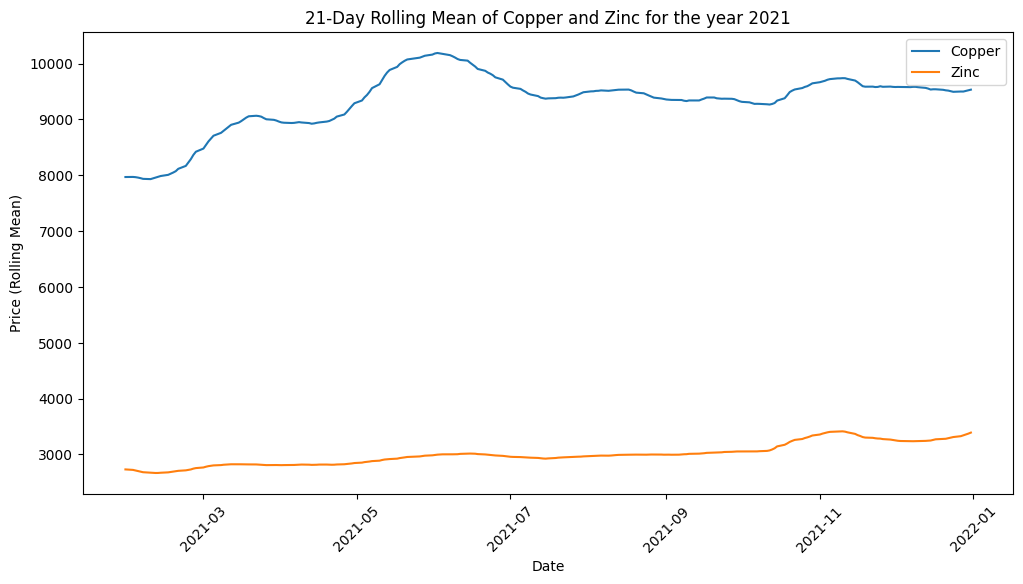

In [16]:
plt.figure(figsize=(12,6))

plt.plot(filtered_metals_average_per_month["Dates"], filtered_metals_average_per_month["Copper_avg_per_month"], label="Copper")
plt.plot(filtered_metals_average_per_month["Dates"], filtered_metals_average_per_month["Zinc_avg_per_month"], label="Zinc")

plt.legend()
plt.title("21-Day Rolling Mean of Copper and Zinc for the year 2021")
plt.xlabel("Date")
plt.ylabel("Price (Rolling Mean)")
plt.xticks(rotation=45)

plt.show()

From the above Visualisation, it can be seen that on an average, Copper has been at about $5000 higher than Zinc on a monthly basis in the year 2021.

The average price per month for each metal, i.e. Copper Aluminum, Zinc, Lead and Tin, have also been calculated and plotted:

In [ ]:
metal_columns = ["Copper", "Aluminum", "Zinc", "Lead", "Tin"]

# Utilising the df DataFrame since this is for all the metals in the DataFrame, to build on it for calculating the 
# average price per month as appending columns in this new DataFrame for this purpose:
df_metals_average_per_month = df.copy()

for metal_column in metal_columns:
    df_metals_average_per_month[metal_column + "_avg_per_month"] = df_metals_average_per_month[metal_column].rolling(window=21).mean()

Plotting the Visualisation for the same:

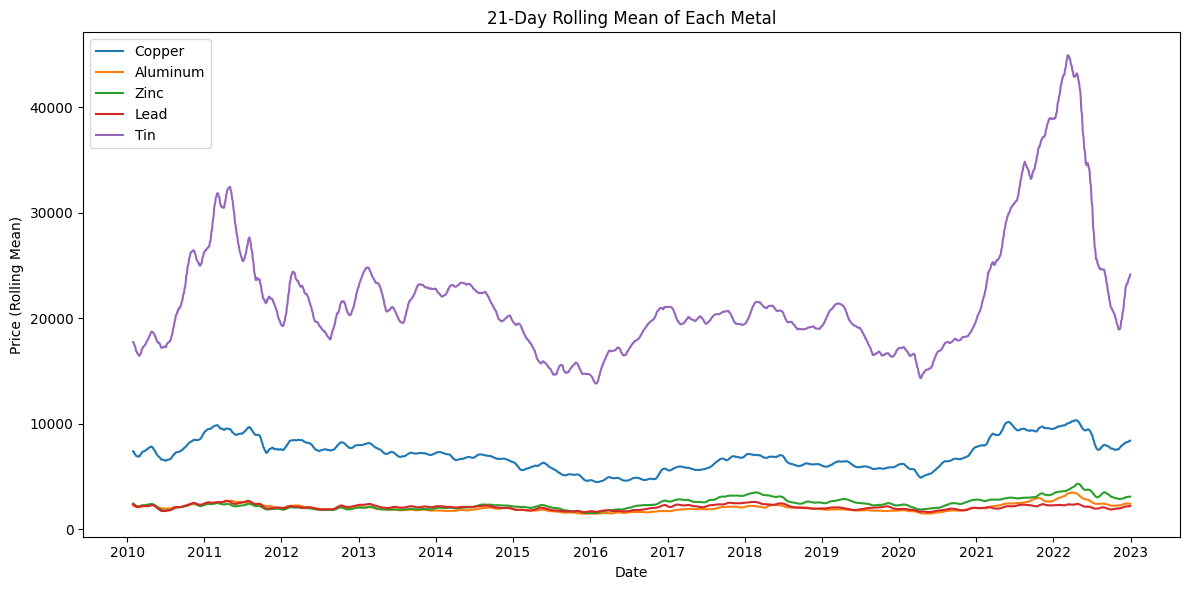

In [18]:
# Converting Dates column into date object, in order to utilise this in the formatting of the x-axis label in the 
# visualisation below:
df["Dates"] = pd.to_datetime(df["Dates"], dayfirst=True)

plt.figure(figsize=(12, 6))

plt.plot(df["Dates"], df_metals_average_per_month["Copper_avg_per_month"],   label="Copper")
plt.plot(df["Dates"], df_metals_average_per_month["Aluminum_avg_per_month"], label="Aluminum")
plt.plot(df["Dates"], df_metals_average_per_month["Zinc_avg_per_month"],     label="Zinc")
plt.plot(df["Dates"], df_metals_average_per_month["Lead_avg_per_month"],     label="Lead")
plt.plot(df["Dates"], df_metals_average_per_month["Tin_avg_per_month"],      label="Tin")

plt.legend()
plt.title("21-Day Rolling Mean of Each Metal")
plt.xlabel("Date")
plt.ylabel("Price (Rolling Mean)")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

Therefore, from the above Visualisation, it can be seen that on an average, Tin has had the highest prices relative to all the other metals here. Copper is the next highest on average as well. While Zinc, Lead and Aluminum have been around the same, on an average, till about 2016, and then these 3 metals have been varying from each other till the end of the year 2022 in terms of this calculation.